In [1]:
#all necessary imports
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# TA indicators
import ta
from ta.trend import PSARIndicator

# Data Normalization and Scaling
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Scikit-learn utilities
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# hyperparameter optimization
import optuna
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Training device:", device)

print("Torch version:", torch.__version__)
print("Polars version:", pl.__version__)
print("TQDM imported successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("TA library imported successfully!")
print("Optuna version:",optuna.__version__)

Training device: cuda
Torch version: 2.5.1+cu121
Polars version: 0.20.26
TQDM imported successfully!
NumPy version: 1.26.4
Pandas version: 2.2.2
TA library imported successfully!
Optuna version: 4.8.0


c:\Users\User\miniconda3\envs\quant_dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Data preprocessing function
# change this to the desired stock ticker
company = "aapl"
files = [ f"{company.lower()}_daily.csv"]
dfs = [pl.read_csv(f, try_parse_dates=True) for f in files]

combined_df = pl.concat(dfs)

combined_df = combined_df.sort(["ticker", "datetime"])

print(combined_df)

shape: (9_688, 40)
┌────────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬────────┐
│ datetime   ┆ open_price ┆ high_pric ┆ low_price ┆ … ┆ target_t2 ┆ target_t3 ┆ target_t4 ┆ ticker │
│ ---        ┆ ---        ┆ e         ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---    │
│ datetime[μ ┆ f64        ┆ ---       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ str    │
│ s]         ┆            ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆        │
╞════════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪════════╡
│ 1987-07-02 ┆ 0.357143   ┆ 0.366071  ┆ 0.35491   ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ AAPL   │
│ 21:30:00   ┆            ┆           ┆           ┆   ┆           ┆           ┆           ┆        │
│ 1987-07-06 ┆ 0.362723   ┆ 0.372767  ┆ 0.361607  ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ AAPL   │
│ 21:30:00   ┆            ┆           ┆           ┆   ┆           ┆     

In [3]:
# All features + targets pre-computed in old_data_columns.py
df = combined_df.to_pandas()
df = df.sort_values(["ticker", "datetime"]).reset_index(drop=True)
print(df.head())

             datetime  open_price  high_price  low_price  close_price  \
0 1987-07-02 21:30:00    0.357143    0.366071   0.354910     0.362723   
1 1987-07-06 21:30:00    0.362723    0.372767   0.361607     0.363839   
2 1987-07-07 21:30:00    0.363839    0.366071   0.345982     0.350446   
3 1987-07-08 21:30:00    0.350446    0.350446   0.325893     0.332589   
4 1987-07-09 21:30:00    0.332589    0.345982   0.332589     0.337053   

        volume      PSAR  trend  psar_distance_pct  ma_200_percent  ...  \
0   81558480.0  0.382651      0          -5.494003        0.435449  ...   
1   85489684.0  0.381541      0          -4.865441        0.433850  ...   
2  204310604.0  0.380476      0          -8.569114        0.375639  ...   
3  342630740.0  0.378406      0         -13.776003        0.301069  ...   
4  239747436.0  0.374205      0         -11.022716        0.314014  ...   

   close_minus_ema  close_minus_psar  bars_since_swing_high  \
0         0.002711         -0.019928           

In [4]:
# removing rows with NaN values
df = df.dropna().reset_index(drop=True)
print(df)

                datetime  open_price  high_price   low_price  close_price  \
0    1987-07-02 21:30:00    0.357143    0.366071    0.354910     0.362723   
1    1987-07-06 21:30:00    0.362723    0.372767    0.361607     0.363839   
2    1987-07-07 21:30:00    0.363839    0.366071    0.345982     0.350446   
3    1987-07-08 21:30:00    0.350446    0.350446    0.325893     0.332589   
4    1987-07-09 21:30:00    0.332589    0.345982    0.332589     0.337053   
...                  ...         ...         ...         ...          ...   
9683 2026-05-26 21:30:00  309.560000  311.820000  307.670000   308.330000   
9684 2026-05-27 21:30:00  308.330000  313.260000  308.300000   310.850000   
9685 2026-05-28 21:30:00  310.680000  312.800000  309.570000   312.510000   
9686 2026-05-29 21:30:00  311.775000  315.000000  309.530000   312.060000   
9687 2026-06-01 21:30:00  309.625000  310.940000  305.020000   306.310000   

           volume        PSAR  trend  psar_distance_pct  ma_200_percent  ..

In [5]:
TRAIN_CUTOFF = pd.Timestamp("2018-12-31")

train_list = []
test_list  = []

for ticker in df["ticker"].unique():
    ticker_df = df[df["ticker"] == ticker].sort_values("datetime").reset_index(drop=True)
    train_list.append(ticker_df[ticker_df["datetime"] <= TRAIN_CUTOFF])
    test_list.append(ticker_df[ticker_df["datetime"] >  TRAIN_CUTOFF])

train_df = pd.concat(train_list).sort_values(["ticker", "datetime"]).reset_index(drop=True)
test_df  = pd.concat(test_list).sort_values(["ticker", "datetime"]).reset_index(drop=True)

print(f"Train rows: {len(train_df):,}")
print(f"Test rows : {len(test_df):,}")
print(f"\nTrain/Test split per ticker:")
for ticker in df["ticker"].unique():
    tr = len(train_df[train_df["ticker"] == ticker])
    te = len(test_df[test_df["ticker"]  == ticker])
    tr_end   = train_df[train_df["ticker"] == ticker]["datetime"].max()
    te_start = test_df[test_df["ticker"]  == ticker]["datetime"].min()
    print(f"  {ticker}: train={tr:,} (up to {tr_end.date()}) | "
          f"test={te:,} (from {te_start.date()})")

Train rows: 7,848
Test rows : 1,840

Train/Test split per ticker:
  AAPL: train=7,848 (up to 2018-12-28) | test=1,840 (from 2018-12-31)


In [6]:
df_test = df[df["datetime"] > pd.Timestamp("2018-12-31")].copy()
naive_acc = (df_test["trend"] == df_test["target_t1"]).mean()
print(f"Naive persistence acc : {naive_acc:.4f}")
print(f"Model t+1 acc         : 0.8593")
print(f"Lift over naive       : {0.8593 - naive_acc:.4f}")

Naive persistence acc : 0.9092
Model t+1 acc         : 0.8593
Lift over naive       : -0.0499


leakage check

In [6]:
ticker = f"{company.upper()}"
train_aapl = train_df[train_df["ticker"] == ticker].sort_values("datetime")
test_aapl  = test_df[test_df["ticker"]   == ticker].sort_values("datetime")

print("── Last 5 training rows ──")
print(train_aapl.tail(5)[["datetime", "target_t1", "target_t2", "target_t3", "target_t4"]])

print("\n── First 5 test rows ──")
print(test_aapl.head(5)[["datetime", "target_t1"]])

── Last 5 training rows ──
                datetime  target_t1  target_t2  target_t3  target_t4
7843 2018-12-21 22:30:00        0.0        0.0        0.0        0.0
7844 2018-12-24 22:30:00        0.0        0.0        0.0        1.0
7845 2018-12-26 22:30:00        0.0        0.0        1.0        1.0
7846 2018-12-27 22:30:00        0.0        1.0        1.0        0.0
7847 2018-12-28 22:30:00        1.0        1.0        0.0        0.0

── First 5 test rows ──
             datetime  target_t1
0 2018-12-31 22:30:00        1.0
1 2019-01-02 22:30:00        0.0
2 2019-01-03 22:30:00        0.0
3 2019-01-04 22:30:00        0.0
4 2019-01-07 22:30:00        0.0


In [7]:
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np
import os

features = [
    'hl_range_pct', 'close_pct_change', 'volume_ratio', 'trend', 'ma_200_percent',
    'rsi', 'bb_position', 'rsi_slope', 'rsi_divergence', 'macd_histogram',
    'macd_hist_slope', 'adx', 'adx_slope', 'upper_wick_atr', 'lower_wick_atr',
    'bars_since_swing_high', 'bars_since_swing_low', 'close_minus_ema',
    'close_minus_psar', 'return_5', 'volatility_10', 'upper_wick_ratio',
    'lower_wick_ratio', 'body_ratio', 'ATR_percent', 'bb_width',
    'psar_distance_pct', 'fractal_swing_phase',
]
target_cols = ['target_t1', 'target_t2', 'target_t3', 'target_t4']

TICKERS     = [f"{company.upper()}"]
WINDOW_SIZE = 30
HORIZON     = 4
SCALE_CLIP  = 5.0
scalers     = {}

X_train_list, y_train_list = [], []
X_test_list,  y_test_list  = [], []

for ticker in TICKERS:
    print(f"\nProcessing {ticker}...")

    train_tk = train_df[train_df["ticker"] == ticker].sort_values("datetime").reset_index(drop=True)
    test_tk  = test_df[test_df["ticker"]   == ticker].sort_values("datetime").reset_index(drop=True)

    if len(train_tk) == 0 or len(test_tk) == 0:
        print(f"  WARNING — no data for {ticker}, skipping.")
        continue

    sc = StandardScaler()
    train_feat_scaled = sc.fit_transform(train_tk[features].values)
    test_feat_scaled  = sc.transform(test_tk[features].values)

    train_feat_scaled = np.clip(train_feat_scaled, -SCALE_CLIP, SCALE_CLIP)
    test_feat_scaled  = np.clip(test_feat_scaled,  -SCALE_CLIP, SCALE_CLIP)
    scalers[ticker]   = sc

    print(f"  Train: {len(train_tk):,} rows | "
          f"scaled min/max: {train_feat_scaled.min():.3f} / {train_feat_scaled.max():.3f}")
    print(f"  Test : {len(test_tk):,} rows  | "
          f"scaled min/max: {test_feat_scaled.min():.3f} / {test_feat_scaled.max():.3f}")

    train_targets = train_tk[target_cols].values   # (N, 4) — already forward-labeled
    test_targets  = test_tk[target_cols].values

    for i in range(WINDOW_SIZE, len(train_feat_scaled)):
        X_train_list.append(train_feat_scaled[i - WINDOW_SIZE:i])
        y_train_list.append(train_targets[i])      # (4,) — no sliding needed

    for i in range(WINDOW_SIZE, len(test_feat_scaled)):
        X_test_list.append(test_feat_scaled[i - WINDOW_SIZE:i])
        y_test_list.append(test_targets[i])

# ── Stack ─────────────────────────────────────────────────────────────────────
X_train = np.array(X_train_list)   # (n, 30, 28)
y_train = np.array(y_train_list)   # (n, 4)
X_test  = np.array(X_test_list)    # (n, 30, 28)
y_test  = np.array(y_test_list)    # (n, 4)

path = f"{company}"
os.makedirs(path, exist_ok=True)
joblib.dump(scalers, f"{path}/{company}_per_ticker.pkl")

print("\n── Final Shapes ──────────────────────────────────────────")
print(f"X_train: {X_train.shape}  — (n, {WINDOW_SIZE}, {len(features)})")
print(f"y_train: {y_train.shape}  — (n, {HORIZON} horizons)")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")
print(f"\nX_train min/max: {X_train.min():.4f} / {X_train.max():.4f}")
print(f"X_test  min/max: {X_test.min():.4f}  / {X_test.max():.4f}")
print(f"\ny_train unique: {np.unique(y_train)}")
print(f"y_test  unique: {np.unique(y_test)}")
print(f"\nTotal train sequences: {len(X_train):,}")
print(f"Total test  sequences: {len(X_test):,}")


Processing AAPL...
  Train: 7,848 rows | scaled min/max: -5.000 / 5.000
  Test : 1,840 rows  | scaled min/max: -5.000 / 5.000

── Final Shapes ──────────────────────────────────────────
X_train: (7818, 30, 28)  — (n, 30, 28)
y_train: (7818, 4)  — (n, 4 horizons)
X_test : (1810, 30, 28)
y_test : (1810, 4)

X_train min/max: -5.0000 / 5.0000
X_test  min/max: -5.0000  / 5.0000

y_train unique: [0. 1.]
y_test  unique: [0. 1.]

Total train sequences: 7,818
Total test  sequences: 1,810


In [8]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=30, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)

        # Build positional encoding matrix (max_len, d_model)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()        # (30, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)   # even indices
        pe[:, 1::2] = torch.cos(position * div_term)   # odd indices
        pe = pe.unsqueeze(0)                            # (1, 30, d_model)

        # Register as buffer — not a parameter, but saved with model
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# v2
class StockTrendTransformer(nn.Module):
    def __init__(self, input_size=28, d_model=64, nhead=8, num_layers=3,
                 dim_feedforward=256, horizon=4, dropout=0.2,
                 max_len=30, pooling="last"):   # ← add pooling param
        super(StockTrendTransformer, self).__init__()
        self.d_model  = d_model
        self.horizon  = horizon
        self.pooling  = pooling               # ← store it

        self.input_proj = nn.Linear(input_size, d_model)

        # CLS token needed only if pooling="cls"
        if pooling == "cls":
            self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
            self.pos_encoder = PositionalEncoding(d_model, max_len + 1, dropout)
        else:
            self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            batch_first     = True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        self.bn      = nn.BatchNorm1d(d_model)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(d_model, horizon)

    def forward(self, x):
        out = self.input_proj(x)              # (batch, 30, d_model)

        # Prepend CLS token if needed
        if self.pooling == "cls":
            cls = self.cls_token.expand(x.size(0), -1, -1)  # (batch, 1, d_model)
            out = torch.cat([cls, out], dim=1)               # (batch, 31, d_model)

        out = self.pos_encoder(out)
        out = self.transformer_encoder(out)   # (batch, 30or31, d_model)

        # ── Pooling strategy ──────────────────────────────────────────────────
        if self.pooling == "last":
            out = out[:, -1, :]               # last timestep
        elif self.pooling == "mean":
            out = out.mean(dim=1)             # average all timesteps
        elif self.pooling == "cls":
            out = out[:, 0, :]               # CLS token at position 0

        out = self.bn(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

In [9]:
# Verify output shape before training
model_test = StockTrendTransformer(input_size=28).to("cpu")
dummy      = torch.zeros(8, 30, 28)
output     = model_test(dummy)
print("Output shape:", output.shape)   # must be (8, 4)

total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


Output shape: torch.Size([8, 4])
Trainable parameters: 152,196


In [10]:
# training loop setup starts here
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS      = 100 # reduced for quick testing; increase to for real training
BATCH_SIZE  = 32
LR          = 1e-3
PATIENCE    = 15          # early stopping patience
HORIZON     = 4           # t+1 … t+4

print(f"Training on: {DEVICE}")

Training on: cuda


In [11]:
# DATASET & DATALOADER
X_train_t = torch.tensor(X_train, dtype=torch.float32)  # was X_train_scaled
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)  # was X_test_scaled
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [12]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_train_t = torch.tensor(X_train, dtype=torch.float32)  # was X_train_scaled
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)  # was X_test_scaled
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

In [13]:
def objective(trial):

    # ── Hyperparameters ───────────────────────────────────────────────────────
    model_config    = trial.suggest_categorical("model_config", [
        "32_2", "32_4",
        "64_2", "64_4", "64_8",
        "96_4", "96_8",
        "128_4", "128_8"
    ])
    d_model, nhead  = [int(x) for x in model_config.split("_")]

    ff_multiplier   = trial.suggest_categorical("ff_multiplier",     [2, 4])
    dim_feedforward = d_model * ff_multiplier
    num_layers      = trial.suggest_int("num_layers",                 1, 4)
    dropout         = trial.suggest_float("dropout",                  0.1, 0.4, step=0.1)
    lr              = trial.suggest_float("lr",                       1e-4, 1e-2, log=True)
    weight_decay    = trial.suggest_float("weight_decay",             1e-5, 1e-2, log=True)
    batch_size      = trial.suggest_categorical("batch_size",         [32, 64])
    factor          = trial.suggest_float("factor",                   0.3, 0.8, step=0.1)
    patience_sch    = trial.suggest_int("scheduler_patience",         3, 7)
    pooling         = trial.suggest_categorical("pooling",            ["last", "mean", "cls"])
    # ↑ separate suggest_categorical call — not merged into model_config

    # ── Loaders ───────────────────────────────────────────────────────────────
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

    # ── Build model with pooling param ────────────────────────────────────────
    model = StockTrendTransformer(
        input_size      = 28,
        d_model         = d_model,
        nhead           = nhead,
        num_layers      = num_layers,
        dim_feedforward = dim_feedforward,
        horizon         = 4,
        dropout         = dropout,
        max_len         = 30,
        pooling         = pooling    # ← pass pooling to model
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience_sch, factor=factor
    )

    OPTUNA_EPOCHS   = 30
    OPTUNA_PATIENCE = 7
    best_val_loss   = float("inf")
    patience_count  = 0

    for epoch in range(1, OPTUNA_EPOCHS + 1):

        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(X_batch), y_batch).item()
        val_loss /= len(test_loader)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= OPTUNA_PATIENCE:
            break

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_loss

In [14]:
# Optimization here
study = optuna.create_study(
    direction = "minimize",
    pruner    = optuna.pruners.MedianPruner(
        n_startup_trials = 5,
        n_warmup_steps   = 5
    )
)

print("Starting Optuna search for Transformer — 50 trials...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# ── Results
best = study.best_params
d_model, nhead = [int(x) for x in best["model_config"].split("_")]

print("\n" + "=" * 50)
print("OPTUNA SEARCH COMPLETE")
print("=" * 50)
print(f"Best val_loss   : {study.best_value:.4f}")
print(f"d_model         : {d_model}")
print(f"nhead           : {nhead}")
print(f"dim_feedforward : {d_model * best['ff_multiplier']}")
for k, v in best.items():
    if k != "model_config":
        print(f"  {k:<22}: {v}")

Starting Optuna search for Transformer — 50 trials...


Best trial: 29. Best value: 0.453214: 100%|██████████| 50/50 [19:32<00:00, 23.44s/it]


OPTUNA SEARCH COMPLETE
Best val_loss   : 0.4532
d_model         : 64
nhead           : 8
dim_feedforward : 256
  ff_multiplier         : 4
  num_layers            : 2
  dropout               : 0.1
  lr                    : 0.00037990175761941586
  weight_decay          : 0.0017850686086850905
  batch_size            : 64
  factor                : 0.4
  scheduler_patience    : 4
  pooling               : last


Training starts here

In [15]:
best = study.best_params
d_model, nhead = [int(x) for x in best["model_config"].split("_")]
dim_feedforward = d_model * best["ff_multiplier"]

print("Training Transformer with Optuna best params:")
print(f"  {'d_model':<22}: {d_model}")
print(f"  {'nhead':<22}: {nhead}")
print(f"  {'dim_feedforward':<22}: {dim_feedforward}")
for k, v in best.items():
    if k not in ["model_config", "ff_multiplier"]:
        print(f"  {k:<22}: {v}")

Training Transformer with Optuna best params:
  d_model               : 64
  nhead                 : 8
  dim_feedforward       : 256
  num_layers            : 2
  dropout               : 0.1
  lr                    : 0.00037990175761941586
  weight_decay          : 0.0017850686086850905
  batch_size            : 64
  factor                : 0.4
  scheduler_patience    : 4
  pooling               : last


In [16]:

d_model, nhead  = [int(x) for x in best["model_config"].split("_")]
dim_feedforward = d_model * best["ff_multiplier"]

print("Best Optuna params:")
print(f"  d_model         : {d_model}")
print(f"  nhead           : {nhead}")
print(f"  dim_feedforward : {dim_feedforward}")
for k, v in best.items():
    if k not in ["model_config", "ff_multiplier"]:
        print(f"  {k:<22}: {v}")

# ── Build model with best params ──────────────────────────────────────────────
model = StockTrendTransformer(
    input_size      = 28,
    d_model         = d_model,
    nhead           = nhead,
    num_layers      = best["num_layers"],
    dim_feedforward = dim_feedforward,
    horizon         = HORIZON,
    dropout         = best["dropout"],
    max_len         = WINDOW_SIZE,
    pooling         = best["pooling"]
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = best["lr"],
    weight_decay = best["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min",
    patience = best["scheduler_patience"],
    factor   = best["factor"]
)

# ── Verify ────────────────────────────────────────────────────────────────────
print(f"\nTraining on     : {DEVICE}")
print(f"Initial LR      : {optimizer.param_groups[0]['lr']:.6f}")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters      : {total_params:,}")
print(f"d_model         : {model.d_model}")
print(f"nhead           : {nhead}")
print(f"num_layers      : {best['num_layers']}")
print(f"dim_feedforward : {dim_feedforward}")
print(f"pooling         : {model.pooling}")
print(f"dropout         : {best['dropout']}")
print(f"horizon         : {model.horizon}")

Best Optuna params:
  d_model         : 64
  nhead           : 8
  dim_feedforward : 256
  num_layers            : 2
  dropout               : 0.1
  lr                    : 0.00037990175761941586
  weight_decay          : 0.0017850686086850905
  batch_size            : 64
  factor                : 0.4
  scheduler_patience    : 4
  pooling               : last

Training on     : cuda
Initial LR      : 0.000380
Parameters      : 102,212
d_model         : 64
nhead           : 8
num_layers      : 2
dim_feedforward : 256
pooling         : last
dropout         : 0.1
horizon         : 4


In [17]:
#  3. HELPER: EVALUATE ON ANY LOADER
def evaluate(model, loader, criterion, device):
    """
    Returns avg loss, per-horizon accuracy, per-horizon F1.
    model.eval() + torch.no_grad() ensures no gradient computation.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)                       # raw logits (batch, 4)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item()

            probs  = torch.sigmoid(logits)                # convert to probabilities
            preds  = (probs > 0.5).float()                # threshold → 0 or 1

            all_preds.append(preds.cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())

    all_preds  = np.concatenate(all_preds,  axis=0)      # (N, 4)
    all_labels = np.concatenate(all_labels, axis=0)      # (N, 4)

    # Per-horizon metrics (column = t+1, t+2, t+3, t+4)
    accs = [accuracy_score(all_labels[:, h], all_preds[:, h]) for h in range(HORIZON)]
    f1s  = [f1_score(all_labels[:, h], all_preds[:, h], zero_division=0) for h in range(HORIZON)]

    avg_loss = total_loss / len(loader)
    return avg_loss, accs, f1s


In [18]:
# Training Loop with early stopping
history = {
    "train_loss": [], "val_loss": [],
    "val_acc": [],    "val_f1":  []
}

best_val_loss  = float("inf")
patience_count = 0
best_weights   = None

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN PHASE ──────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()              # clear gradients from last step

        logits = model(X_batch)            # forward pass
        loss   = criterion(logits, y_batch)

        loss.backward()                    # backpropagation

        # Gradient clipping — prevents exploding gradients (critical for LSTMs)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()                   # update weights
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── VALIDATION PHASE ─────────────────────────────────────────────────────
    val_loss, val_accs, val_f1s = evaluate(model, test_loader, criterion, DEVICE)

    # Step scheduler based on val_loss
    scheduler.step(val_loss)

    # Log history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(np.mean(val_accs))    # mean across horizons
    history["val_f1"].append(np.mean(val_f1s))

    # ── EARLY STOPPING ───────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
        tag = "best"
    else:
        patience_count += 1
        tag = f" {patience_count}/{PATIENCE}"


    current_lr = optimizer.param_groups[0]["lr"]

    # Print every 10 epochs
    # if epoch % 10 == 0 or epoch == 1:
    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {np.mean(val_accs):.4f} | "
        f"Val F1: {np.mean(val_f1s):.4f} | "
        f"LR: {current_lr:.6f} | "
        f"{tag}"
    )

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best val_loss was at epoch {epoch - PATIENCE}: {best_val_loss:.4f}")
        break

# Restore best weights
if best_weights is not None:
    model.load_state_dict(best_weights)
    print(f"\nRestored best model (val_loss={best_val_loss:.4f})")
else:
    print("\nWarning: No best weights saved — using final weights")

Epoch 001 | Train Loss: 0.5191 | Val Loss: 0.4657 | Val Acc: 0.7778 | Val F1: 0.8197 | LR: 0.000380 | best
Epoch 002 | Train Loss: 0.4852 | Val Loss: 0.4659 | Val Acc: 0.7801 | Val F1: 0.8171 | LR: 0.000380 |  1/15
Epoch 003 | Train Loss: 0.4736 | Val Loss: 0.4508 | Val Acc: 0.7895 | Val F1: 0.8267 | LR: 0.000380 | best
Epoch 004 | Train Loss: 0.4718 | Val Loss: 0.4521 | Val Acc: 0.7876 | Val F1: 0.8296 | LR: 0.000380 |  1/15
Epoch 005 | Train Loss: 0.4652 | Val Loss: 0.4695 | Val Acc: 0.7776 | Val F1: 0.8153 | LR: 0.000380 |  2/15
Epoch 006 | Train Loss: 0.4652 | Val Loss: 0.4588 | Val Acc: 0.7776 | Val F1: 0.8122 | LR: 0.000380 |  3/15
Epoch 007 | Train Loss: 0.4642 | Val Loss: 0.4584 | Val Acc: 0.7822 | Val F1: 0.8231 | LR: 0.000380 |  4/15
Epoch 008 | Train Loss: 0.4581 | Val Loss: 0.4533 | Val Acc: 0.7838 | Val F1: 0.8191 | LR: 0.000152 |  5/15
Epoch 009 | Train Loss: 0.4572 | Val Loss: 0.4554 | Val Acc: 0.7829 | Val F1: 0.8209 | LR: 0.000152 |  6/15
Epoch 010 | Train Loss: 0.4531

In [19]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix
)

def evaluate_detailed(model, loader, criterion, device, horizon=4):
    model.eval()
    total_loss = 0.0
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            total_loss += criterion(logits, y_batch).item()
            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())
            all_preds.append((probs > 0.5).float().cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())

    all_probs  = np.concatenate(all_probs,  axis=0)   # (N, 4)
    all_preds  = np.concatenate(all_preds,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    avg_loss   = total_loss / len(loader)

    lines = []
    lines.append(f"Company:{company}")
    lines.append(f"\nFinal Test Loss : {avg_loss:.4f}")
    lines.append(f"Test sequences  : {len(all_labels):,}")
    lines.append("")
    lines.append(f"{'Horizon':<8} {'Acc':>7} {'F1':>7} {'Prec':>7} {'Rec':>7} {'AUC':>7} {'Pred↑%':>8} {'True↑%':>8}")
    lines.append("─" * 64)

    for h in range(horizon):
        y_true = all_labels[:, h]
        y_pred = all_preds[:, h]
        y_prob = all_probs[:, h]

        acc   = accuracy_score(y_true, y_pred)
        f1    = f1_score(y_true, y_pred, zero_division=0)
        prec  = precision_score(y_true, y_pred, zero_division=0)
        rec   = recall_score(y_true, y_pred, zero_division=0)
        auc   = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")
        pred_up_pct = y_pred.mean() * 100
        true_up_pct = y_true.mean() * 100

        lines.append(
            f"  t+{h+1:<5} {acc:>7.4f} {f1:>7.4f} {prec:>7.4f} {rec:>7.4f} "
            f"{auc:>7.4f} {pred_up_pct:>7.1f}% {true_up_pct:>7.1f}%"
        )

    lines.append("─" * 64)
    lines.append(
        f"  {'Mean':<6} "
        f"{np.mean([accuracy_score(all_labels[:,h], all_preds[:,h]) for h in range(horizon)]):>7.4f} "
        f"{np.mean([f1_score(all_labels[:,h], all_preds[:,h], zero_division=0) for h in range(horizon)]):>7.4f}"
    )

    # Confusion matrix per horizon
    lines.append("\nConfusion Matrices (TN FP / FN TP):")
    for h in range(horizon):
        tn, fp, fn, tp = confusion_matrix(all_labels[:, h], all_preds[:, h]).ravel()
        lines.append(f"  t+{h+1}: TN={tn:5,}  FP={fp:5,}  FN={fn:5,}  TP={tp:5,}")

    output_text = "\n".join(lines)
    print(output_text)

    os.makedirs(path, exist_ok=True)
    with open(f"{path}/evaluation_{company}.txt", "w") as f:
        f.write(output_text)

    return output_text

evaluate_detailed(model, test_loader, criterion, DEVICE, HORIZON)

Company:aapl

Final Test Loss : 0.4508
Test sequences  : 1,810

Horizon      Acc      F1    Prec     Rec     AUC   Pred↑%   True↑%
────────────────────────────────────────────────────────────────
  t+1      0.8707  0.8926  0.8812  0.9042  0.9380    60.9%    59.4%
  t+2      0.8127  0.8458  0.8281  0.8643  0.8797    62.0%    59.4%
  t+3      0.7602  0.8007  0.7934  0.8082  0.8247    60.7%    59.6%
  t+4      0.7144  0.7678  0.7467  0.7902  0.7684    63.3%    59.8%
────────────────────────────────────────────────────────────────
  Mean    0.7895  0.8267

Confusion Matrices (TN FP / FN TP):
  t+1: TN=  604  FP=  131  FN=  103  TP=  972
  t+2: TN=  541  FP=  193  FN=  146  TP=  930
  t+3: TN=  504  FP=  227  FN=  207  TP=  872
  t+4: TN=  438  FP=  290  FN=  227  TP=  855


'Company:aapl\n\nFinal Test Loss : 0.4508\nTest sequences  : 1,810\n\nHorizon      Acc      F1    Prec     Rec     AUC   Pred↑%   True↑%\n────────────────────────────────────────────────────────────────\n  t+1      0.8707  0.8926  0.8812  0.9042  0.9380    60.9%    59.4%\n  t+2      0.8127  0.8458  0.8281  0.8643  0.8797    62.0%    59.4%\n  t+3      0.7602  0.8007  0.7934  0.8082  0.8247    60.7%    59.6%\n  t+4      0.7144  0.7678  0.7467  0.7902  0.7684    63.3%    59.8%\n────────────────────────────────────────────────────────────────\n  Mean    0.7895  0.8267\n\nConfusion Matrices (TN FP / FN TP):\n  t+1: TN=  604  FP=  131  FN=  103  TP=  972\n  t+2: TN=  541  FP=  193  FN=  146  TP=  930\n  t+3: TN=  504  FP=  227  FN=  207  TP=  872\n  t+4: TN=  438  FP=  290  FN=  227  TP=  855'

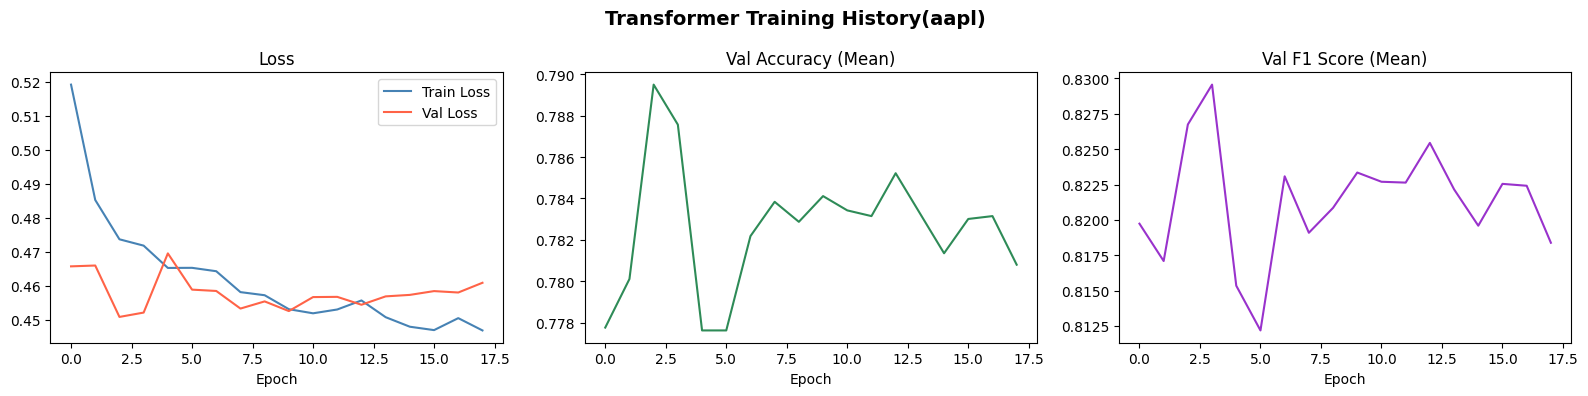

In [20]:
# ── 6. PLOT TRAINING CURVES
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Transformer Training History({company})', fontsize=14, fontweight="bold")

axes[0].plot(history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(history["val_loss"],   label="Val Loss",   color="tomato")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history["val_acc"], color="seagreen")
axes[1].set_title("Val Accuracy (Mean)"); axes[1].set_xlabel("Epoch")

axes[2].plot(history["val_f1"], color="darkorchid")
axes[2].set_title("Val F1 Score (Mean)"); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(f'{path}/Transformer_training_history({company}).png', dpi=150)
plt.show()

In [21]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state":  optimizer.state_dict(),
    "val_loss":         best_val_loss,
    "history":          history,
    "config": {
        "input_size":       28,
        "d_model":          d_model,
        "nhead":            nhead,
        "num_layers":       best["num_layers"],
        "dim_feedforward":  dim_feedforward,
        "horizon":          HORIZON,
        "dropout":          best["dropout"],
        "window_size":      WINDOW_SIZE,
        "max_len":          WINDOW_SIZE,
        "pooling":          best["pooling"],
        "lr":               best["lr"],
        "weight_decay":     best["weight_decay"],
        "batch_size":       best["batch_size"],
        "factor":           best["factor"],
        "scheduler_patience": best["scheduler_patience"],
    }
}, f'Transformer_best({company}).pt')
print(f'Model saved to Transformer_best({company}).pt')

# ── Verify saved config ───────────────────────────────────────────────────────
os.makedirs(path, exist_ok=True)
ck = torch.load(f'{path}/Transformer_best({company}).pth', map_location="cpu", weights_only=False)
print("\nSaved config:")
for k, v in ck["config"].items():
    print(f"  {k:<22}: {v}")
print(f"  {'val_loss':<22}: {ck['val_loss']:.4f}")

Model saved to Transformer_best(aapl).pt


FileNotFoundError: [Errno 2] No such file or directory: 'aapl/Transformer_best(aapl).pth'